### Cell 1: นำเข้า Library ที่จำเป็น
เซลล์นี้ทำหน้าที่เรียกใช้เครื่องมือต่างๆ ที่จำเป็นสำหรับการทำงาน:
- `os`: สำหรับจัดการเส้นทางไฟล์และโฟลเดอร์
- `pandas` และ `numpy`: สำหรับจัดการตารางข้อมูล (Dataframe) และการคำนวณตัวเลข
- `matplotlib` และ `seaborn`: สำหรับสร้างกราฟและ Visualization ทั้ง 3 รูปแบบ
- `warnings`: ปิดการแจ้งเตือนจุกจิกเพื่อความสะอาดของ Output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
import os

# ปิดการแจ้งเตือน (Warnings) ที่ไม่จำเป็นเพื่อให้ Output อ่านง่ายขึ้น
warnings.filterwarnings('ignore')

### Cell 2: ฟังก์ชันสำหรับ Data Processing & Cleaning
เซลล์นี้ประกอบด้วย 2 ฟังก์ชันหลัก:
1. `clean_taxonomy`: รับ Taxonomy string เข้ามาตัดแบ่งด้วยเครื่องหมาย `;` หรือ `.` จากนั้นเช็คว่าระดับ Rank ที่เราต้องการมันคือ "uncultured", "unknown" ฯลฯ หรือไม่ ถ้าใช่ จะถอยกลับไปหา Rank ที่สูงกว่าที่ระบุชื่อได้ พร้อมใส่วงเล็บกำกับไว้ เช่น `Armatimonadota (p)`
2. `process_microbiome_data`: โหลดไฟล์ทั้งสองไฟล์ คำนวณ `% Relative Abundance` กรองข้อมูลด้วยค่า Cut-off ที่ผู้ใช้กำหนด และนำข้อมูล Feature กับ LEfSe มาผสานกันเพื่อให้มั่นใจว่าเรามีข้อมูลครบถ้วนสำหรับการสร้างกราฟ

In [2]:
def clean_taxonomy(taxa_string, target_rank='g', sep=';'):
    """
    ฟังก์ชันทำความสะอาด Taxonomy String รองรับการ Fallback ไปยัง Rank ที่สูงกว่า
    หากพบคำที่ไม่สามารถระบุได้ เช่น 'Incertae_Sedis', 'uncultured', หรือ 'unknown'
    """
    ranks = ['d', 'p', 'c', 'o', 'f', 'g']
    if target_rank not in ranks:
        raise ValueError(f"Invalid rank. โปรดเลือกจาก {ranks}")
    
    # แยก Taxonomy string ด้วยเครื่องหมายที่กำหนด (เช่น ; สำหรับ Feature, . สำหรับ LEfSe)
    parts = str(taxa_string).split(sep)
    taxa_dict = {}
    
    # ดึงข้อมูลจาก format rank__name เข้าเก็บใน Dictionary
    for part in parts:
        if '__' in part:
            try:
                r, name = part.split('__', 1)
                if r == 'k': r = 'd' # อนุโลมใช้ k (Kingdom) แทน d (Domain)
                taxa_dict[r.strip()] = name.strip()
            except ValueError:
                continue
                
    target_idx = ranks.index(target_rank)
    invalid_keywords = ['uncultured', 'unknown', 'incertae_sedis', 'incertae sedis']
    
    # ถอยหลังเช็คจาก Target Rank ไปจนถึง Domain เพื่อหาชื่อที่ระบุได้
    for i in range(target_idx, -1, -1):
        r = ranks[i]
        name = taxa_dict.get(r, '')
        
        # ตรวจสอบว่าเป็นคำที่ไม่มีความหมาย (invalid) หรือไม่
        is_invalid = (name == '') or any(kw in name.lower() for kw in invalid_keywords)
        
        if not is_invalid:
            if i == target_idx:
                return name # คืนค่าชื่อปกติถ้าระบุได้ใน Rank ที่ต้องการ
            else:
                return f"{name} ({r})" # ถ้าต้องถอยกลับ ให้ใส่วงเล็บ Rank นั้นๆ เช่น (p)
                
    return "Unknown"

def process_microbiome_data(feature_file, lefse_file, 
                            taxonomic_rank='g', 
                            percent_cutoff=0.1, 
                            lda_score_cutoff=2.0, 
                            p_value_cutoff=0.05):
    """
    ฟังก์ชันหลักสำหรับเตรียมข้อมูล คำนวณ % Relative Abundance และผสานกับข้อมูล LEfSe
    """
    # 1. จัดการข้อมูล Feature Table
    df_feat = pd.read_csv(feature_file)
    df_feat = df_feat.set_index(df_feat.columns[0]) # ตั้งคอลัมน์แรก (Sample ID) เป็น Index
    
    # ดึงคอลัมน์สุดท้ายมาเป็นข้อมูลกลุ่ม ไม่ว่าคอลัมน์นั้นจะชื่ออะไร (เช่น Group หรือ Agriculture_practice)
    groups = df_feat.iloc[:, -1]
    # แยกเอาเฉพาะข้อมูลตัวเลข Abundance (ดึงมาทุกคอลัมน์ยกเว้นคอลัมน์สุดท้าย)
    df_abund = df_feat.iloc[:, :-1]
    
    # คำนวณ % Relative Abundance: (Abundance ของ Taxa / ผลรวม Abundance ใน Sample นั้น) * 100
    df_rel = df_abund.div(df_abund.sum(axis=1), axis=0) * 100
    
    # ทำความสะอาดชื่อ Taxa โดยเรียกใช้ฟังก์ชัน clean_taxonomy (Separator ของข้อมูลนี้คือ ';')
    df_rel.columns = [clean_taxonomy(col, taxonomic_rank, sep=';') for col in df_rel.columns]
    # นำคอลัมน์ที่มีชื่อ Taxa เหมือนกัน (ผลจากการ Fallback) มารวมผลบวกเข้าด้วยกัน
    df_rel = df_rel.groupby(df_rel.columns, axis=1).sum()
    
    # กรองเอาเฉพาะ Taxa ที่มีค่าเฉลี่ย % Relative Abundance มากกว่าหรือเท่ากับ Cut-off
    mean_abund = df_rel.mean(axis=0)
    df_rel = df_rel.loc[:, mean_abund >= percent_cutoff]
    
    # 2. จัดการข้อมูล LEfSe
    df_lefse = pd.read_csv(lefse_file, sep='\t') # อ่านไฟล์ lefse.txt ด้วยการคั่นแบบ Tab
    
    # จัดการเปลี่ยนชื่อคอลัมน์ให้อ้างอิงง่ายขึ้น ป้องกัน Error จากชื่อคอลัมน์ที่ไม่ตรงเป๊ะๆ
    df_lefse.rename(columns={
        'Taxonomy / Feature': 'Taxa/Feature',
        'LDA score (log10)': 'LDA score'
    }, inplace=True)
    
    # แปลงข้อมูลตัวเลขให้แน่ใจว่าไม่มีข้อผิดพลาด (ถ้าเจอ '-' ปล่อยข้ามหรือแก้เป็น NaN แล้วลบออก)
    df_lefse['LDA score'] = pd.to_numeric(df_lefse['LDA score'], errors='coerce')
    df_lefse['p-value'] = pd.to_numeric(df_lefse['p-value'], errors='coerce')
    df_lefse = df_lefse.dropna(subset=['LDA score', 'p-value'])
    
    # กรองข้อมูล LEfSe ให้เหลือเฉพาะตัวที่ผ่าน Cut-off ของ LDA score และ p-value
    df_lefse = df_lefse[(df_lefse['LDA score'] >= lda_score_cutoff) & 
                        (df_lefse['p-value'] <= p_value_cutoff)]
    
    # ทำความสะอาดชื่อ Taxa ของไฟล์ LEfSe (Separator ของข้อมูลนี้คือ '.')
    df_lefse['Clean_Taxa'] = df_lefse['Taxa/Feature'].apply(lambda x: clean_taxonomy(x, taxonomic_rank, sep='.')).values
    
    # 3. หาส่วนร่วมของข้อมูลทั้ง 2 ตาราง (เก็บเฉพาะ Taxa ที่มีในทั้งคู่)
    valid_taxa = df_lefse['Clean_Taxa'].unique()
    common_taxa = [t for t in valid_taxa if t in df_rel.columns]
    
    # ตัดแบ่งตารางข้อมูลให้เหลือแค่ Taxa ที่ผ่านเงื่อนไข
    df_rel_filtered = df_rel[common_taxa]
    df_lefse_filtered = df_lefse[df_lefse['Clean_Taxa'].isin(common_taxa)]
    
    return df_rel_filtered, df_lefse_filtered, groups

### Cell 3: ฟังก์ชันสำหรับสร้าง Visualizations
เซลล์นี้มีหน้าที่วาดกราฟทั้ง 3 รูปแบบตาม Requirement พร้อมระบบสร้างโฟลเดอร์และเซฟภาพอัตโนมัติ:
1. **`plot_lefse_bar`**: กราฟแท่งแสดงค่า LDA Score โดยมีการแยกแกนซ้าย-ขวา ตามกลุ่ม Class (พ่นสีแบ่งกลุ่ม)
2. **`plot_microbiome_heatmap`**: แผนภาพความร้อน (Heatmap) ที่นำข้อมูล Relative Abundance มาดูแพทเทิร์น พร้อมทำ Clustering (แผนผังต้นไม้) และใส่แถบสีแยกกลุ่มตามข้อมูล Group
3. **`plot_bubble_chart`**: กราฟฟองสบู่ที่ใช้ขนาดฟองแทน % Relative abundance (แกน X คือ Samples, แกน Y คือ Taxa)

In [3]:
def plot_lefse_bar(df_lefse, save_format='png', output_dir='outputs',
                   rank='g', pct_cutoff=0.1, lda_cutoff=2.0, p_cutoff=0.05):
    """
    สร้าง LEfSe Plot แยกลักษณะแกน X บวก/ลบตาม Class
    """
    if df_lefse.empty:
        print("\n ไม่มีข้อมูลที่ผ่าน Cut-off สำหรับวาด LEfSe Plot")
        return
        
    plt.figure(figsize=(10, 8))
    # จัดการคอลัมน์ Class เอาเฉพาะที่มีค่า
    df_lefse_clean = df_lefse.dropna(subset=['Class'])
    classes = df_lefse_clean['Class'].unique()
    
    # ถ้ามี 2 Classes ให้กลับเครื่องหมาย (คูณ -1) ของกลุ่มนึง เพื่อให้แท่งกราฟชี้ไปฝั่งซ้าย
    if len(classes) == 2:
        class_1, class_2 = classes[0], classes[1]
        df_plot = df_lefse_clean.copy()
        df_plot.loc[df_plot['Class'] == class_2, 'LDA score'] *= -1
    else:
        df_plot = df_lefse_clean.copy()
        
    # เรียงลำดับข้อมูลจากน้อยไปมาก เพื่อความสวยงามของกราฟแท่ง
    df_plot = df_plot.sort_values('LDA score')
    
    # สร้างพจนานุกรมสี
    palette_colors = {classes[0]: 'green', classes[1]: 'red'} if len(classes) == 2 else None
    
    # วาดกราฟแท่ง (Barplot)
    if palette_colors:
        sns.barplot(x='LDA score', y='Clean_Taxa', hue='Class', data=df_plot, palette=palette_colors, dodge=False)
    else:
        sns.barplot(x='LDA score', y='Clean_Taxa', data=df_plot)
        
    plt.axvline(0, color='black', linewidth=1) # ลากเส้นแบ่งตรงกลาง (LDA = 0)
    
    # ตั้งชื่อกราฟและป้ายกำกับแกน
    plt.title(f'LEfSe LDA Scores\n(Rank={rank}, Abundance≥{pct_cutoff}%, LDA≥{lda_cutoff}, p≤{p_cutoff})', fontsize=16)
    plt.xlabel('LDA Score (log 10)', fontsize=12)
    plt.ylabel('Taxonomy', fontsize=12)
    plt.tight_layout()
    
    # สร้างโฟลเดอร์ outputs หากยังไม่มี และเซฟรูป
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'lefse_plot_rank{rank}_pct{pct_cutoff}_lda{lda_cutoff}_p{p_cutoff}.{save_format}'), dpi=300, format=save_format)
    plt.show()

def plot_microbiome_heatmap(df_rel, groups, save_format='png', output_dir='outputs',
                             rank='g', pct_cutoff=0.1, lda_cutoff=2.0, p_cutoff=0.05):
    """
    สร้าง Heatmap แบบ Cluster โดยมีแถบสีบอกกลุ่ม Metadata (Farm Group)
    """
    if df_rel.empty:
        print("\n ไม่มีข้อมูลที่ผ่าน Cut-off สำหรับวาด Heatmap")
        return
        
    # เตรียมชุดสีสำหรับแบ่งกลุ่ม Samples (เช่น Chemical vs Organic)
    group_lut = dict(zip(groups.unique(), sns.color_palette("Set2", len(groups.unique()))))
    col_colors = groups.map(group_lut)
    col_colors.name = 'Group'
    
    # Transpose ข้อมูลเพื่อให้ Rows = Taxa, Columns = Samples ตามที่โจทย์กำหนด
    plot_data = df_rel.T 
    
    # สร้าง Clustermap (Heatmap แบบมี Dendrogram)
    g = sns.clustermap(plot_data,
                       cmap='YlGnBu', 
                       col_colors=col_colors, 
                       figsize=(12, 10),
                       standard_scale=0, # ปรับ Scale ตามแนวนอน (Taxa) ให้เห็นการกระจายตัวชัดขึ้น
                       linewidths=0.5,
                       yticklabels=True,
                       xticklabels=True)
                       
    g.fig.suptitle(f'Microbiome Abundance Heatmap\n(Rank={rank}, Abundance≥{pct_cutoff}%, LDA≥{lda_cutoff}, p≤{p_cutoff})',
               y=1.05, fontsize=16)   
    # เพิ่มคำอธิบายสี (Legend) ของ Group ไว้ตรงกลางของแผนผัง
    for label, color in group_lut.items():
        g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
    g.ax_col_dendrogram.legend(loc="center", ncol=2)
    
    # เซฟรูป
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    g.savefig(os.path.join(output_dir, f'heatmap_plot_rank{rank}_pct{pct_cutoff}_lda{lda_cutoff}_p{p_cutoff}.{save_format}'), dpi=300, format=save_format)
    plt.show()

def plot_bubble_chart(df_rel, save_format='png', output_dir='outputs',
                      rank='g', pct_cutoff=0.1, lda_cutoff=2.0, p_cutoff=0.05):
    """
    สร้าง Bubble Plot ขนาดฟองแปรผันตาม % Relative Abundance
    """
    if df_rel.empty:
        print("\n ไม่มีข้อมูลที่ผ่าน Cut-off สำหรับวาด Bubble Plot")
        return
        
    # แปลงรูปแบบตารางจากแบบกว้าง (Wide) เป็นแบบยาว (Long) เพื่อให้วาดกราฟง่าย
    df_melt = df_rel.reset_index().melt(id_vars='index', var_name='Taxa', value_name='Abundance')
    df_melt.rename(columns={'index': 'Sample'}, inplace=True)
    
    # เอาเฉพาะจุดที่มีค่า Abundance > 0 (ประหยัดพื้นที่และไม่วาดฟองขนาด 0)
    df_melt = df_melt[df_melt['Abundance'] > 0]
    
    plt.figure(figsize=(14, 8))
    # วาด Bubble plot ด้วยฟังก์ชัน Scatterplot โดยกำหนดค่า size = 'Abundance'
    sns.scatterplot(data=df_melt, 
                    x='Sample', 
                    y='Taxa', 
                    size='Abundance', 
                    sizes=(20, 1000), # กำหนดช่วงขนาดของฟอง (เล็กสุด-ใหญ่สุด)
                    hue='Abundance', 
                    palette='viridis', 
                    alpha=0.7)
    
    plt.title(f'Relative Abundance Bubble Plot\n(Rank={rank}, Abundance≥{pct_cutoff}%, LDA≥{lda_cutoff}, p≤{p_cutoff})', fontsize=16)
    plt.xlabel('Samples', fontsize=12)
    plt.ylabel('Taxonomy', fontsize=12)
    plt.xticks(rotation=90)
    
    # ขยับกรอบ Legend ออกไปไว้นอกกราฟ
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Rel. Abundance (%)')
    plt.tight_layout()
    
    # เซฟรูป
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'bubble_plot_rank{rank}_pct{pct_cutoff}_lda{lda_cutoff}_p{p_cutoff}.{save_format}'), dpi=300, format=save_format)
    plt.show()

## Cell 4: Data Inspection Before and After Microbiome Data Processing

Cell นี้ใช้สำหรับตรวจสอบข้อมูลในแต่ละขั้นตอนของการเตรียมข้อมูล microbiome ก่อนนำไปวิเคราะห์ต่อ โดยจะแสดงตัวอย่างข้อมูล 10 แถวแรก พร้อมทั้งรายงานจำนวนแถว (`rows`) และจำนวนคอลัมน์ (`columns`) ของแต่ละตาราง เพื่อช่วยในการ debug และตรวจสอบความถูกต้องของข้อมูล

### ขั้นตอนที่ตรวจสอบ

1. **Before Process**
   - อ่านไฟล์ `feature_table.csv`
   - อ่านไฟล์ `lefse.txt`
   - ตรวจสอบข้อมูลดิบก่อนเริ่ม process

2. **Before Clean**
   - ตั้ง Sample ID เป็น index
   - แยกข้อมูลกลุ่ม (`groups`)
   - แยก abundance table
   - คำนวณ Relative Abundance (%)
   - ตรวจสอบชื่อ taxa ก่อน clean

3. **After Clean**
   - ทำความสะอาดชื่อ taxa ด้วย `clean_taxonomy()`
   - รวม taxa ที่ซ้ำกันหลัง clean
   - ตรวจสอบ Relative Abundance หลัง clean

4. **LEfSe Clean**
   - เปลี่ยนชื่อคอลัมน์ของ LEfSe
   - clean taxa จาก LEfSe
   - ตรวจสอบข้อมูลก่อนและหลัง clean

5. **After Process**
   - เรียกใช้ `process_microbiome_data()`
   - ตรวจสอบผลลัพธ์สุดท้าย:
     - `df_rel_filtered`
     - `df_lefse_filtered`
     - `groups`

### หมายเหตุ

- Cell นี้จะแสดงเฉพาะ 10 แถวแรกของแต่ละ DataFrame เพื่อลดความยาวของ output
- ใช้ helper function `show_df_info()` เพื่อแสดง:
  - Shape ของข้อมูล
  - จำนวน rows และ columns
  - ตัวอย่างข้อมูลส่วนต้น
- เหมาะสำหรับใช้ debug pipeline และตรวจสอบความถูกต้องของข้อมูลก่อนทำ visualization หรือ statistical analysis ต่อ


In [4]:
# ==============================
# IMPORT
# ==============================

import pandas as pd


# ==============================
# DISPLAY SETTINGS
# ==============================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


# ==============================
# HELPER FUNCTION
# ==============================

def show_df_info(name, df, head_rows=10):
    print(f"\n========== {name} ==========")
    print(f"Shape: {df.shape}")
    
    # สำหรับ Series
    if isinstance(df, pd.Series):
        print(f"Total Rows: {len(df)}")

        if len(df) > head_rows:
            print(f"\nShowing first {head_rows} rows only:\n")
            display(df.head(head_rows))
        else:
            display(df)

    # สำหรับ DataFrame
    else:
        print(f"Total Rows: {len(df)}")
        print(f"Total Columns: {len(df.columns)}")

        if len(df) > head_rows:
            print(f"\nShowing first {head_rows} rows only:\n")
            display(df.head(head_rows))
        else:
            display(df)


# ==============================
# DEFINE PARAMETERS
# ==============================

feature_file = "inputs/feature_table.csv"
lefse_file = "inputs/lefse.txt"

taxonomic_rank = 'g'
percent_cutoff = 0.1
lda_score_cutoff = 3.0
p_value_cutoff = 0.05


# ==============================
# BEFORE PROCESS
# ==============================

print("\n================ BEFORE PROCESS =================")

# อ่าน feature table
raw_feature = pd.read_csv(feature_file)

show_df_info(
    "RAW FEATURE FILE",
    raw_feature
)

# อ่าน lefse
raw_lefse = pd.read_csv(lefse_file, sep='\t')

show_df_info(
    "RAW LEFSE FILE",
    raw_lefse
)


# ==============================
# BEFORE CLEAN
# ==============================

print("\n================ BEFORE CLEAN =================")

# set sample id เป็น index
df_feat = raw_feature.set_index(raw_feature.columns[0])

show_df_info(
    "FEATURE TABLE AFTER SET INDEX",
    df_feat
)

# groups
groups = df_feat.iloc[:, -1]

show_df_info(
    "GROUPS",
    groups
)

# abundance table
df_abund = df_feat.iloc[:, :-1]

show_df_info(
    "RAW ABUNDANCE TABLE",
    df_abund
)

# relative abundance
df_rel_before = df_abund.div(
    df_abund.sum(axis=1),
    axis=0
) * 100

show_df_info(
    "RELATIVE ABUNDANCE BEFORE CLEAN",
    df_rel_before
)

# taxa before clean
taxa_before_df = pd.DataFrame({
    'Original_Taxa': df_rel_before.columns
})

show_df_info(
    "TAXA BEFORE CLEAN",
    taxa_before_df
)


# ==============================
# AFTER CLEAN
# ==============================

print("\n================ AFTER CLEAN =================")

df_rel_after = df_rel_before.copy()

# clean taxonomy
df_rel_after.columns = [
    clean_taxonomy(col, taxonomic_rank, sep=';')
    for col in df_rel_after.columns
]

# taxa after clean
taxa_after_df = pd.DataFrame({
    'Cleaned_Taxa': df_rel_after.columns
})

show_df_info(
    "TAXA AFTER CLEAN",
    taxa_after_df
)

# รวม taxa ซ้ำ
df_rel_after = df_rel_after.groupby(
    df_rel_after.columns,
    axis=1
).sum()

show_df_info(
    "RELATIVE ABUNDANCE AFTER CLEAN",
    df_rel_after
)


# ==============================
# LEFSE CLEAN
# ==============================

print("\n================ LEFSE CLEAN =================")

df_lefse = raw_lefse.copy()

# rename columns
df_lefse.rename(columns={
    'Taxonomy / Feature': 'Taxa/Feature',
    'LDA score (log10)': 'LDA score'
}, inplace=True)

show_df_info(
    "LEFSE BEFORE CLEAN",
    df_lefse
)

# clean taxa
df_lefse['Clean_Taxa'] = df_lefse['Taxa/Feature'].apply(
    lambda x: clean_taxonomy(
        x,
        taxonomic_rank,
        sep='.'
    )
)

show_df_info(
    "LEFSE AFTER CLEAN",
    df_lefse
)


# ==============================
# RUN process_microbiome_data
# ==============================

print("\n================ RUN process_microbiome_data =================")

df_rel_filtered, df_lefse_filtered, groups = process_microbiome_data(
    feature_file=feature_file,
    lefse_file=lefse_file,
    taxonomic_rank=taxonomic_rank,
    percent_cutoff=percent_cutoff,
    lda_score_cutoff=lda_score_cutoff,
    p_value_cutoff=p_value_cutoff
)


# ==============================
# AFTER PROCESS
# ==============================

print("\n================ AFTER PROCESS =================")

show_df_info(
    "FINAL df_rel_filtered",
    df_rel_filtered
)

show_df_info(
    "FINAL df_lefse_filtered",
    df_lefse_filtered
)

show_df_info(
    "FINAL groups",
    groups
)


================ BEFORE PROCESS =================

========== RAW FEATURE FILE ==========
Shape: (9, 693)
Total Rows: 9
Total Columns: 693


,index,d__Bacteria;p__Chloroflexota;c__Ktedonobacteria;o__Ktedonobacterales;f__Ktedonobacteraceae;g__1921-2,d__Bacteria;p__Planctomycetota;c__Pla4_lineage;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Archaea;p__Thermoproteota;c__Nitrososphaeria;o__Nitrosotaleales;f__Nitrosotaleaceae;g__Incertae_Sedis,d__Bacteria;p__Gemmatimonadota;c__Gemmatimonadia;o__Gemmatimonadales;f__Gemmatimonadaceae;g__Gemmatimonas,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Streptosporangiales;f__Thermomonosporaceae;g__Actinomadura,d__Bacteria;p__Chloroflexota;c__Chloroflexia;o__Chloroflexales;f__Roseiflexaceae;g__Incertae_Sedis,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Streptosporangiales;f__Thermomonosporaceae;__,d__Bacteria;p__Planctomycetota;c__Planctomycetes;o__Gemmatales;f__Gemmataceae;g__Incertae_Sedis,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Streptosporangiales;f__Thermomonosporaceae;g__Thermomonospora,d__Bacteria;p__Chloroflexota;__;__;__;__,d__Bacteria;p__Actinomycetota;c__Acidimicrobiia;o__Acidimicrobiales;f__Acidimicrobiaceae;g__Incertae_Sedis,d__Bacteria;p__Chloroflexota;c__TK10;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiia;o__Chthoniobacterales;f__Chthoniobacteraceae;g__Candidatus_Udaeobacter,d__Bacteria;p__Acidobacteriota;c__Subgroup_22;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Armatimonadota;c__Incertae_Sedis;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Actinomycetota;c__MB-A2-108;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Acidobacteriota;c__Acidobacteriae;o__Terriglobales;__;__,d__Bacteria;p__Chloroflexota;c__Ktedonobacteria;o__Ktedonobacterales;f__Ktedonobacteraceae;g__FCPS473,d__Bacteria;p__Bacillota;c__Bacilli;o__Alicyclobacillales;f__Alicyclobacillaceae;g__Acidibacillus,d__Bacteria;p__Planctomycetota;c__Planctomycetes;o__Pirellulales;f__Pirellulaceae;g__Incertae_Sedis,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Cytophagales;f__Microscillaceae;g__Incertae_Sedis,d__Bacteria;p__Pseudomonadota;c__Alphaproteobacteria;o__Rickettsiales;f__SM2D12;g__Incertae_Sedis,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__Saccharimonadales;f__LWQ8;g__Incertae_Sedis,d__Bacteria;p__Chloroflexota;c__Ktedonobacteria;o__Ktedonobacterales;f__Ktedonobacteraceae;g__HSB_OF53-F07,d__Bacteria;p__Actinomycetota;c__Acidimicrobiia;o__Microtrichales;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Chloroflexota;c__Ktedonobacteria;o__Ktedonobacterales;f__Ktedonobacteraceae;g__Incertae_Sedis,d__Bacteria;p__Bacillota;c__Bacilli;o__Thermoactinomycetales;f__Thermoactinomycetaceae;g__Staphylospora,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__Saccharimonadales;__;__,d__Bacteria;p__Chloroflexota;c__Anaerolineae;o__Aggregatilineales;__;__,d__Bacteria;p__Patescibacteria;c__Saccharimonadia;o__Saccharimonadales;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Latescibacterota;c__Incertae_Sedis;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Chloroflexota;c__JG30-KF-CM66;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Elusimicrobiota;c__Lineage_IIa;o__Incertae_Sedis;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Pseudomonadota;c__Alphaproteobacteria;o__Elsterales;f__Elsteraceae;g__Incertae_Sedis,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Gammaproteobacteria_Incertae_Sedis;f__Unknown_Family;g__Acidibacter,d__Bacteria;p__Acidobacteriota;c__Acidobacteriae;o__Subgroup_2;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Planctomycetota;c__Phycisphaerae;o__Phycisphaerales;f__Phycisphaeraceae;g__Incertae_Sedis,d__Bacteria;p__Armatimonadota;c__Chthonomonadia;o__Chthonomonadales;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Pseudomonadota;c__Alphaproteobacteria;o__Sphingomonadales;f__Sphingomonadaceae;__,d__Bacteria;p__Acidobacteriota;c__Acidobacteriae;o__Terriglobales;f__Incertae_Sedis;g__Incertae_Sedis,d__Bacteria;p__Actinomycetot


========== RAW LEFSE FILE ==========
Shape: (1451, 5)
Total Rows: 1451
Total Columns: 5

Showing first 10 rows only:



,Taxonomy / Feature,LDA score (log10),Class,Mean (relative) abundance in that class,p-value
0,d__Bacteria.p__Chloroflexota.c__Ktedonobacteria.o__Ktedonobacterales.f__Ktedonobacteraceae.g__1921_2,4.133573,NaN,NaN,-
1,d__Bacteria.p__Planctomycetota.c__Pla4_lineage.o__Incertae_Sedis.f__Incertae_Sedis.g__Incertae_Sedis,3.161728,NaN,NaN,-
2,d__Archaea.p__Thermoproteota.c__Nitrososphaeria.o__Nitrosotaleales.f__Nitrosotaleaceae.g__Incertae_Sedis,4.715641,Chemical,4.401727,0.013902988164384317
3,d__Bacteria.p__Gemmatimonadota.c__Gemmatimonadia.o__Gemmatimonadales.f__Gemmatimonadaceae.g__Gemmatimonas,3.635040,NaN,NaN,-
4,d__Bacteria.p__Actinomycetota.c__Actinobacteria.o__Streptosporangiales.f__Thermomonosporaceae.g__Actinomadura,2.915836,NaN,NaN,-
5,d__Bacteria.p__Chloroflexota.c__Chloroflexia.o__Chloroflexales.f__Roseiflexaceae.g__Incertae_Sedis,4.302404,Organic,3.954607,0.014305878435429647
6,d__Bacteria.p__Actinomycetota.c__Actinobacteria.o__Streptosporangiales.f__Thermomonosporaceae.__,3.471210,NaN,NaN,-
7,d__Bacteria.p__Planctomycetota.c__Planctomycetes.o__Gemmatales.f__Gemmataceae.g__Incertae_Sedis,4.378580,NaN,NaN,-
8,d__Bacteria.p__Actinomycetota.c__Actinobacteria.o__Streptosporangiales.f__Thermomonosporaceae.g__Thermomonospora,2.445346,NaN,NaN,-
9,d__Bacteria.p__Chloroflexota.__.__.__.__,3.446578,NaN,NaN,-



================ BEFORE CLEAN =================

========== FEATURE TABLE AFTER SET INDEX ==========
Shape: (9, 692)
Total Rows: 9
Total Columns: 692


...

,Nitrosotaleaceae (f),Roseiflexaceae (f),TK10 (c),Candidatus_Udaeobacter,Armatimonadota (p),Microtrichales (o),Ktedonobacteraceae (f),Latescibacterota (p),Acidibacter,Subgroup_2 (o),Gaiella,Nitrososphaeraceae (f),Elsterales (o),Aggregatilineaceae (f),Subgroup_7 (o),Micromonosporaceae (f),Geminicoccaceae (f),WD2101_soil_group (f),Vicinamibacterales (o),Pirellula,Microvirga,Solirubrobacter,Rokubacteriales (o),Luedemannella,Comamonadaceae (f),Acidothermus,Anaeromyxobacter,bacteriap25 (c),Rubrobacter,Sulfobacillaceae (f),Subgroup_10,S085 (o),Sphingomonas,Acetobacteraceae (f),Eremiobacteria (c),Agromyces,Vicinamibacteraceae (f),Occallatibacter,Solirubrobacterales (o),Marmoricola,Alicyclobacillus,Pyrinomonadaceae (f),Thermoplasmata (c),Acidicaldus,FCPU426 (p),Myxococcaceae (f),Chujaibacter,Actinomycetota (p),Steroidobacteraceae (f),Ellin6067,Candidatus_Alysiosphaera,Candidatus_Nitrosocosmicus,Actinophytocola,Terriglobales (o),Gaiellales (o),Frankiales (o)
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Farm01_25,6.768061,0.000000,0.294677,0.000000,0.060203,0.000000,1.365653,0.000000,2.233840,4.534221,0.000000,0.158428,8.862484,0.000000,0.000000,0.079214,0.000000,0.155260,0.019011,0.000000,0.009506,0.000000,0.000000,0.000000,0.000000,17.585551,0.009506,0.000000,0.000000,0.560837,0.000000,0.000000,0.000000,2.512674,1.457541,0.000000,0.000000,1.023447,0.167934,0.000000,3.447402,0.000000,0.301014,0.399240,0.012674,0.041191,0.652725,0.000000,0.000000,0.000000,0.000000,0.015843,0.000000,0.643219,1.657161,0.047529
Farm02_25,2.506337,0.139417,1.558935,0.430925,0.538657,0.063371,0.548162,0.012674,1.102662,3.048162,0.386565,0.358048,8.887833,0.072877,0.266160,0.614702,0.091888,0.392902,1.394170,0.136248,0.215463,0.320025,0.709759,0.000000,0.237643,7.401774,0.066540,0.272497,0.019011,0.266160,0.174271,0.332700,0.301014,0.877693,0.402408,0.003169,1.283270,0.389734,0.212294,0.015843,1.219899,0.468948,0.139417,0.266160,0.180608,0.155260,0.000000,0.000000,0.076046,0.076046,0.082383,0.136248,0.044360,3.089354,3.653359,0.088720
Farm03_25,9.359949,0.088720,0.665399,0.063371,0.183777,0.133080,2.160963,0.072877,2.807351,5.529151,0.640051,0.313688,3.292142,0.082383,0.139417,0.164766,0.000000,0.177440,1.283270,0.193283,0.082383,0.240811,0.044360,0.000000,0.148923,9.413815,0.000000,0.034854,0.079214,0.139417,0.000000,0.193283,0.513308,0.554499,0.269328,0.000000,0.966413,0.636882,0.000000,0.177440,0.776299,0.098226,0.418251,0.072877,0.807985,0.129911,0.763625,0.000000,0.104563,0.091888,0.000000,0.000000,0.000000,1.606464,5.909379,0.665399
Farm04_25,2.148289,0.912548,1.261090,0.161597,0.817490,0.019011,0.934728,0.282003,0.570342,5.294677,0.605196,0.373891,11.083650,0.202788,0.234474,0.497465,0.117237,0.456274,1.695184,0.250317,0.114068,0.269328,0.874525,0.041191,0.332700,10.402408,0.234474,0.088720,0.126743,0.396071,0.145754,0.224968,0.076046,0.655894,0.396071,0.000000,0.899873,0.513308,0.177440,0.091888,1.242079,0.313688,0.231305,0.282003,0.316857,0.133080,0.025349,0.044360,0.079214,0.145754,0.082383,0.057034,0.072877,2.753485,4.112801,0.095057
Farm05_25,0.000000,1.362484,3.938530,1.451204,1.074144,0.174271,0.722433,0.079214,0.275665,0.456274,1.815589,0.557668,2.553866,0.114068,0.396071,1.343473,0.262991,0.655894,1.723701,0.285171,0.602028,1.226236,1.077313,0.098226,0.510139,3.064005,0.418251,0.193283,1.787072,0.031686,0.202788,0.370722,0.468948,0.373891,0.050697,0.126743,0.674905,0.000000,0.551331,0.516477,0.000000,0.877693,0.022180,0.000000,0.025349,0.221800,0.000000,0.196451,0.082383,0.183777,0.231305,0.278834,0.167934,0.583016,7.211660,0.243980
Farm06_25,0.025349,2.392269,4.765526,0.769962,1.299113,0.548162,0.282003,0.282003,0.326362,0.250317,2.313054,3.542459,1.847275,0.228137,0.462611,1.441698,0.396071,1.140684,3.510773,0.405577,0.503802,1.888466,1.378327,0.171103,0.684411,4.556401,0.497465,0.931559,1.083650,0.000000,0.262991,0.611534,0.874525,0.351711,0.069708,0.180608,2.899240,0.038023,0.906210,0.633714,0.000000,1.039290,0.000000,0.00


========== FINAL df_lefse_filtered ==========
Shape: (108, 6)
Total Rows: 108
Total Columns: 6

Showing first 10 rows only:



,Taxa/Feature,LDA score,Class,Mean (relative) abundance in that class,p-value,Clean_Taxa
2,d__Archaea.p__Thermoproteota.c__Nitrososphaeria.o__Nitrosotaleales.f__Nitrosotaleaceae.g__Incertae_Sedis,4.715641,Chemical,4.401727,0.013903,Nitrosotaleaceae (f)
5,d__Bacteria.p__Chloroflexota.c__Chloroflexia.o__Chloroflexales.f__Roseiflexaceae.g__Incertae_Sedis,4.302404,Organic,3.954607,0.014306,Roseiflexaceae (f)
11,d__Bacteria.p__Chloroflexota.c__TK10.o__Incertae_Sedis.f__Incertae_Sedis.g__Incertae_Sedis,4.575094,Organic,4.103303,0.014306,TK10 (c)
12,d__Bacteria.p__Verrucomicrobiota.c__Verrucomicrobiia.o__Chthoniobacterales.f__Chthoniobacteraceae.g__Candidatus_Udaeobacter,3.951728,Organic,3.598183,0.014306,Candidatus_Udaeobacter
14,d__Bacteria.p__Armatimonadota.c__Incertae_Sedis.o__Incertae_Sedis.f__Incertae_Sedis.g__Incertae_Sedis,4.004654,Organic,3.457340,0.027486,Armatimonadota (p)
24,d__Bacteria.p__Actinomycetota.c__Acidimicrobiia.o__Microtrichales.f__Incertae_Sedis.g__Incertae_Sedis,3.633763,Organic,3.217882,0.014306,Microtrichales (o)
25,d__Bacteria.p__Chloroflexota.c__Ktedonobacteria.o__Ktedonobacterales.f__Ktedonobacteraceae.g__Incertae_Sedis,4.097735,Chemical,3.593769,0.027486,Ktedonobacteraceae (f)
30,d__Bacteria.p__Latescibacterota.c__Incertae_Sedis.o__Incertae_Sedis.f__Incertae_Sedis.g__Incertae_Sedis,3.852659,Organic,3.564801,0.027486,Latescibacterota (p)
34,d__Bacteria.p__Pseudomonadota.c__Gammaproteobacteria.o__Gammaproteobacteria_Incertae_Sedis.f__Unknown_Family.g__Acidibacter,4.224934,Chemical,3.810674,0.014306,Acidibacter
35,d__Bacteria.p__Acidobacteriota.c__Acidobacteriae.o__Subgroup_2.f__Incertae_Sedis.g__Incertae_Sedis,4.662904,Chemical,4.244913,0.014306,Subgroup_2 (o)



========== FINAL groups ==========
Shape: (9,)
Total Rows: 9


index
Farm01_25    Chemical
Farm02_25    Chemical
Farm03_25    Chemical
Farm04_25    Chemical
Farm05_25     Organic
Farm06_25     Organic
Farm07_25     Organic
Farm08_25     Organic
Farm09_25     Organic
Name: Agriculture_practice, dtype: object

### Cell 5: วัตถุประสงค์ที่ 1 เพื่อศึกษาผลของการเลือก taxonomic rank, ค่า LDA cut-off และ %relative abundance cut-off ที่มีต่อความสามารถในการแสดง differential abundance pattern ของจุลินทรีย์ ระหว่างฟาร์มอินทรีย์และฟาร์มเคมี


In [5]:
# =========================================================
# Objective 1:
# Effect of taxonomic rank, abundance cutoff, and LDA cutoff
# =========================================================

import pandas as pd
import numpy as np

# 1. กำหนดชื่อไฟล์ Input (ชี้ไปยังโฟลเดอร์ inputs/ ตามโครงสร้างโปรเจค)
FEATURE_FILE = 'inputs/feature_table.csv'
LEFSE_FILE = 'inputs/lefse.txt'
OUTPUT_DIR = 'outputs'

# -----------------------------
# กำหนด parameter ที่จะทดลอง
# -----------------------------
RANKS = ['f', 'g']

PCT_CUTOFFS = [0.01, 0.1, 0.5]

LDA_CUTOFFS = [2.0, 3.0, 4.0]

PVAL_CUTOFF = 0.05

# -----------------------------
# เก็บผลลัพธ์
# -----------------------------
results = []

# -----------------------------
# เริ่มทดลองทุก combination
# -----------------------------
for rank in RANKS:
    
    for pct_cutoff in PCT_CUTOFFS:
        
        for lda_cutoff in LDA_CUTOFFS:
            
            print(f'Running: Rank={rank}, '
                  f'Abundance={pct_cutoff}, '
                  f'LDA={lda_cutoff}')
            
            try:
                
                # -----------------------------
                # ประมวลผลข้อมูล
                # -----------------------------
                df_rel_filtered, df_lefse_filtered, sample_groups = process_microbiome_data(
                    feature_file=FEATURE_FILE,
                    lefse_file=LEFSE_FILE,
                    taxonomic_rank=rank,
                    percent_cutoff=pct_cutoff,
                    lda_score_cutoff=lda_cutoff,
                    p_value_cutoff=PVAL_CUTOFF
                )
                
                # -----------------------------
                # จำนวน taxa
                # -----------------------------
                num_taxa = len(
                    df_lefse_filtered['Clean_Taxa'].unique()
                )
                
                # -----------------------------
                # ค่าเฉลี่ย LDA score
                # -----------------------------
                if not df_lefse_filtered.empty:
                    mean_lda = df_lefse_filtered['LDA score'].mean()
                else:
                    mean_lda = np.nan
                
                # -----------------------------
                # เก็บผลลัพธ์
                # -----------------------------
                results.append({
                    'Taxonomic_Rank': rank,
                    'Relative_Abundance_Cutoff': pct_cutoff,
                    'LDA_Cutoff': lda_cutoff,
                    'Number_of_Significant_Taxa': num_taxa,
                    'Mean_LDA_Score': round(mean_lda, 3)
                })
                
            except Exception as e:
                
                print(f'Error: {e}')
                
                results.append({
                    'Taxonomic_Rank': rank,
                    'Relative_Abundance_Cutoff': pct_cutoff,
                    'LDA_Cutoff': lda_cutoff,
                    'Number_of_Significant_Taxa': np.nan,
                    'Mean_LDA_Score': np.nan
                })

# -----------------------------
# สร้าง DataFrame สรุปผล
# -----------------------------
results_df = pd.DataFrame(results)

# -----------------------------
# เรียงผลลัพธ์
# -----------------------------
results_df = results_df.sort_values(
    by=[
        'Taxonomic_Rank',
        'Relative_Abundance_Cutoff',
        'LDA_Cutoff'
    ]
)

# -----------------------------
# แสดงผล
# -----------------------------
print('\n===== Experiment Results =====')
display(results_df)

# -----------------------------
# Export CSV
# -----------------------------
results_df.to_csv(
    'outputs/objective1_results.csv',
    index=False
)

print('\nResults saved to:')
print('outputs/objective1_results.csv')

Running: Rank=f, Abundance=0.01, LDA=2.0
Running: Rank=f, Abundance=0.01, LDA=3.0
Running: Rank=f, Abundance=0.01, LDA=4.0
Running: Rank=f, Abundance=0.1, LDA=2.0
Running: Rank=f, Abundance=0.1, LDA=3.0
Running: Rank=f, Abundance=0.1, LDA=4.0
Running: Rank=f, Abundance=0.5, LDA=2.0
Running: Rank=f, Abundance=0.5, LDA=3.0
Running: Rank=f, Abundance=0.5, LDA=4.0
Running: Rank=g, Abundance=0.01, LDA=2.0
Running: Rank=g, Abundance=0.01, LDA=3.0
Running: Rank=g, Abundance=0.01, LDA=4.0
Running: Rank=g, Abundance=0.1, LDA=2.0
Running: Rank=g, Abundance=0.1, LDA=3.0
Running: Rank=g, Abundance=0.1, LDA=4.0
Running: Rank=g, Abundance=0.5, LDA=2.0
Running: Rank=g, Abundance=0.5, LDA=3.0
Running: Rank=g, Abundance=0.5, LDA=4.0

===== Experiment Results =====


,Taxonomic_Rank,Relative_Abundance_Cutoff,LDA_Cutoff,Number_of_Significant_Taxa,Mean_LDA_Score
0,f,0.01,2.0,86,3.538
1,f,0.01,3.0,63,3.818
2,f,0.01,4.0,22,4.468
3,f,0.10,2.0,60,3.779
4,f,0.10,3.0,55,3.899
5,f,0.10,4.0,21,4.452
6,f,0.50,2.0,30,4.110
7,f,0.50,3.0,29,4.198
8,f,0.50,4.0,20,4.438
9,g,0.01,2.0,105,3.555



Results saved to:
outputs/objective1_results.csv


### Cell 6: วัตถุประสงค์ที่ 2 เพื่อศึกษาผลของรูปแบบ visualization ที่มี ต่อความชัดเจนในการแสดง dominant taxa และ abundance pattern ของ จุลินทรีย์
เซลล์นี้คือจุดที่เราจะเข้าไปแก้ไขค่า Parameter ต่างๆ เพื่อรันโปรแกรม:
- กำหนด `FEATURE_FILE` และ `LEFSE_FILE` ให้ชี้ไปที่ข้อมูลดิบในโฟลเดอร์ `inputs/`
- สามารถเปลี่ยนค่า Cut-off ได้อิสระตามการทดลอง เช่น `taxonomic_rank` (เลือกระดับ d, p, c, o, f, g), `% Cutoff`, `LDA score`, `p-value`
- เลือกว่าจะ Export เป็นรูปนามสกุล `png` หรือ `pdf` ได้ที่ตัวแปร `SAVE_FORMAT`

Data processing completed successfully!

Generating LEfSe Plot...


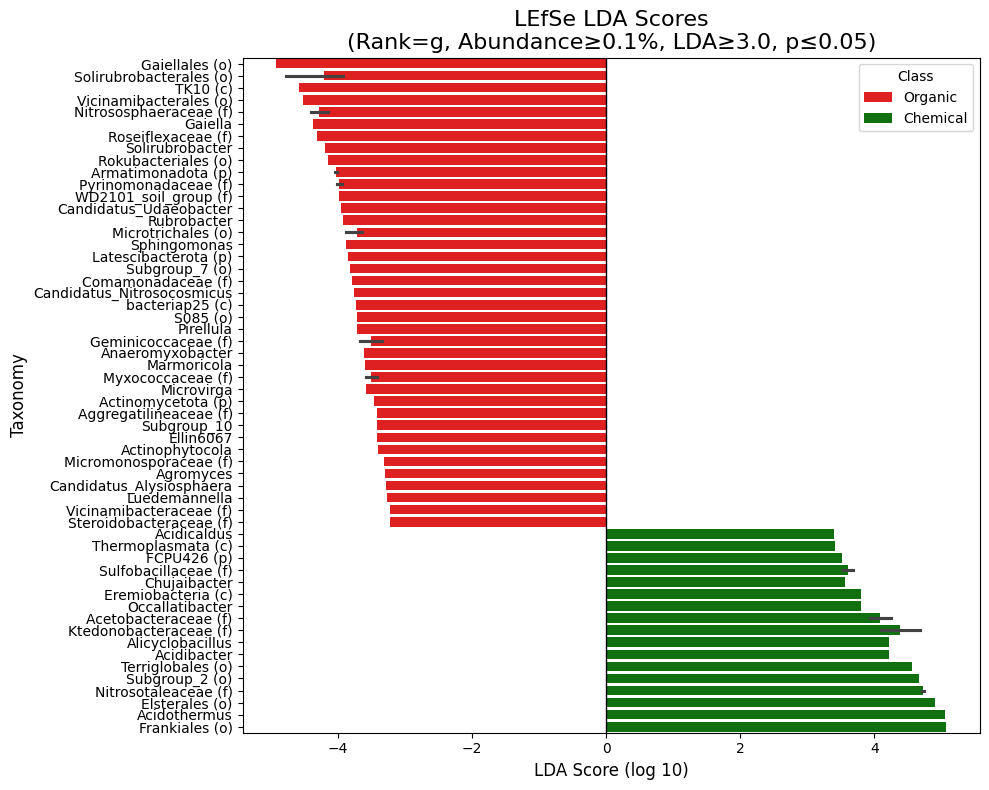

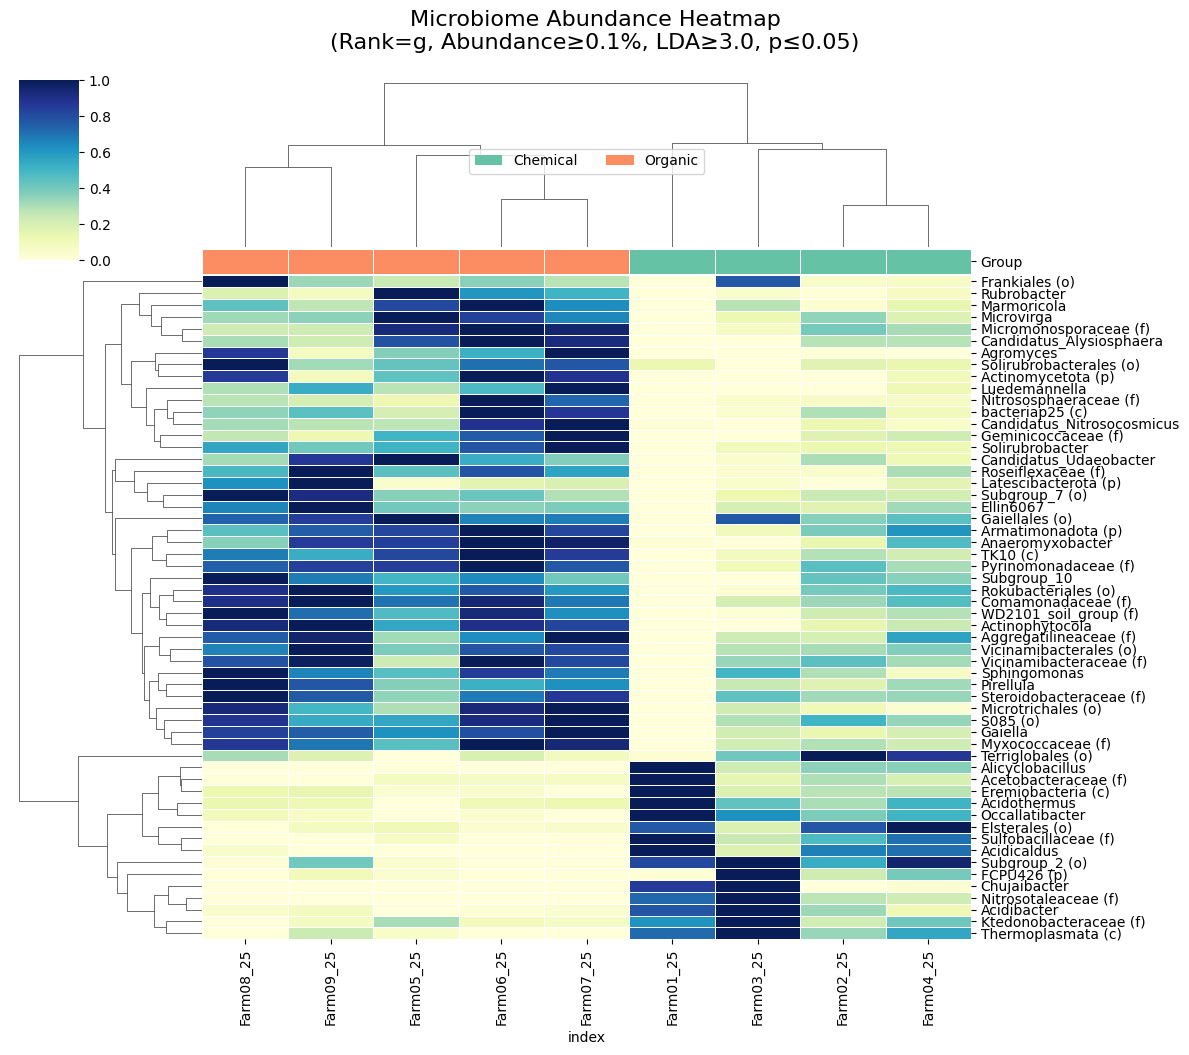

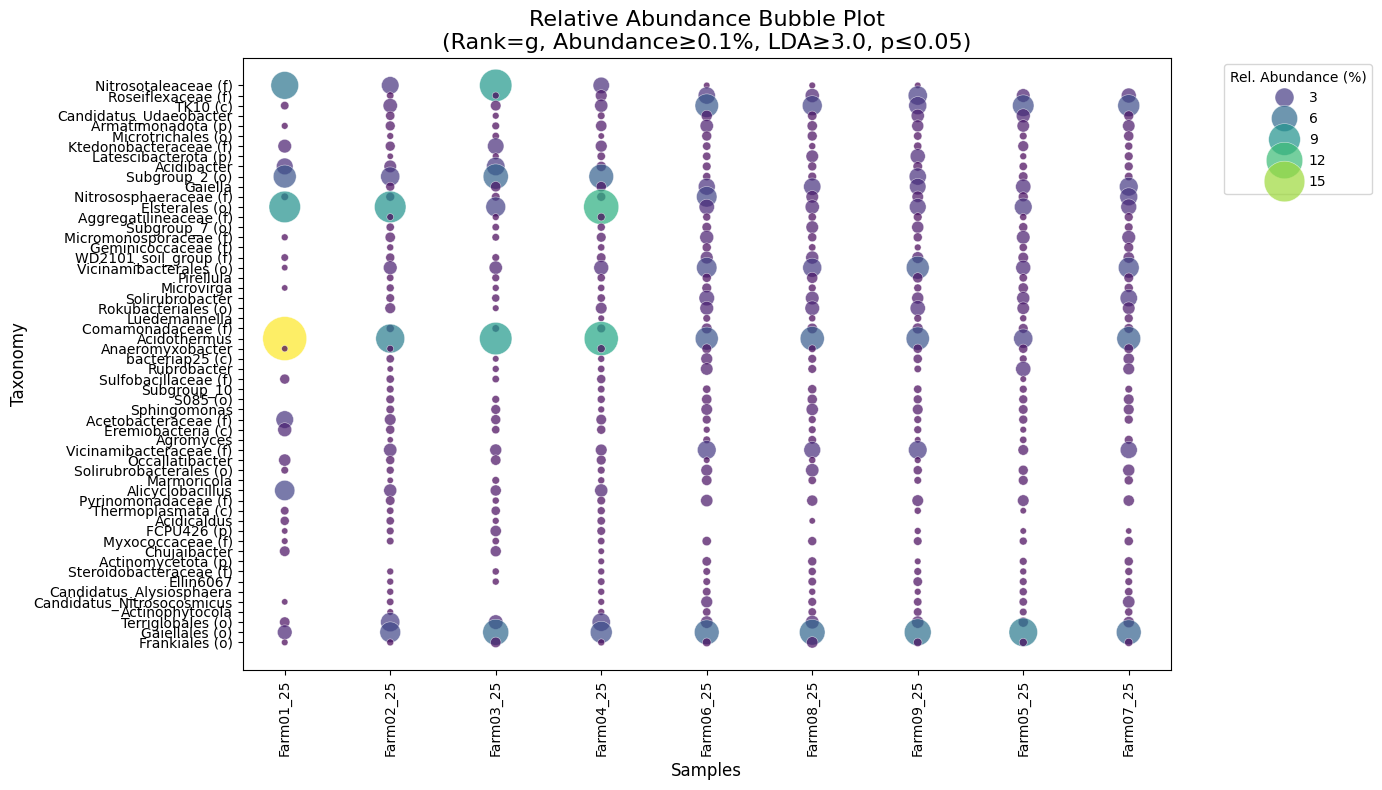

In [6]:
# 1. กำหนดชื่อไฟล์ Input (ชี้ไปยังโฟลเดอร์ inputs/ ตามโครงสร้างโปรเจค)
FEATURE_FILE = 'inputs/feature_table.csv'
LEFSE_FILE = 'inputs/lefse.txt'
OUTPUT_DIR = 'outputs'

try:
    #ค่านี้มาจากวัตถุประสงค์ที่ 1
    RANK       = 'g'              # เลือกระดับ Rank (เช่น g = Genus, f = Family)
    PCT_CUTOFF = 0.1              # เลือกระดับ  Relative Abundance ที่น้อยกว่า 0.1% ทิ้ง
    LDA_CUTOFF = 3.0              # ตัด LDA score ที่น้อยกว่า 3.0 ทิ้ง
    PVAL_CUTOFF = 0.05            # ตัด p-value ที่มากกว่า 0.05 ทิ้ง

    # 2. ประมวลผลข้อมูล (เรียกใช้ฟังก์ชันหลักเพื่อเตรียมข้อมูล)
    df_rel_filtered, df_lefse_filtered, sample_groups = process_microbiome_data(
        feature_file=FEATURE_FILE,
        lefse_file=LEFSE_FILE,
        taxonomic_rank=RANK,               
        percent_cutoff=PCT_CUTOFF,        
        lda_score_cutoff=LDA_CUTOFF,       
        p_value_cutoff=PVAL_CUTOFF       
    )
    
    print("Data processing completed successfully!")
    
    # 3. กำหนดนามสกุลไฟล์สำหรับการ Export กราฟ (รองรับ 'png' หรือ 'pdf')
    SAVE_FORMAT = 'png'
    
    # 4. สร้างและบันทึก Visualization ทั้ง 3 แบบ
    print("\nGenerating LEfSe Plot...")
    plot_lefse_bar(df_lefse_filtered, save_format=SAVE_FORMAT, output_dir=OUTPUT_DIR,
               rank=RANK, pct_cutoff=PCT_CUTOFF, lda_cutoff=LDA_CUTOFF, p_cutoff=PVAL_CUTOFF)

    plot_microbiome_heatmap(df_rel_filtered, sample_groups, save_format=SAVE_FORMAT, output_dir=OUTPUT_DIR,
               rank=RANK, pct_cutoff=PCT_CUTOFF, lda_cutoff=LDA_CUTOFF, p_cutoff=PVAL_CUTOFF)

    plot_bubble_chart(df_rel_filtered, save_format=SAVE_FORMAT, output_dir=OUTPUT_DIR,
               rank=RANK, pct_cutoff=PCT_CUTOFF, lda_cutoff=LDA_CUTOFF, p_cutoff=PVAL_CUTOFF)

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("กรุณาตรวจสอบว่ามีไฟล์อยู่ในโฟลเดอร์ inputs/ หรือไม่")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

### Cell 7: วัตถุประสงค์ที่ 3 เพื่อศึกษาอิทธิพลของรูปแบบการเกษตรที่มีต่อ composition และ relative abundance ของชุมชนจุลินทรีย์ในดิน


In [7]:
# ============================================
# OBJECTIVE 3 : วิเคราะห์อิทธิพลของรูปแบบการเกษตร
# ============================================

# กำหนด parameter ที่ต้องการสำหรับ Objective 3 อย่างชัดเจน
df_rel_filtered, df_lefse_filtered, sample_groups = process_microbiome_data(
    feature_file=FEATURE_FILE,
    lefse_file=LEFSE_FILE,
    taxonomic_rank='g',
    percent_cutoff=0.1,
    lda_score_cutoff=3.0,
    p_value_cutoff=0.05
)

# --------------------------------------------
# 1) taxa เด่นของแต่ละกลุ่ม
# --------------------------------------------

print("========== Significant Taxa ==========\n")

significant_taxa = df_lefse_filtered[
    ['Clean_Taxa', 'Class', 'LDA score', 'p-value']
].drop_duplicates(subset=['Clean_Taxa'])

print(f"Total significant taxa = {len(significant_taxa)}")

display(significant_taxa)

# export csv
significant_taxa.to_csv(
    f"{OUTPUT_DIR}/significant_taxa.csv",
    index=False
)

print(f"\nTotal significant taxa = {len(significant_taxa)}")


# --------------------------------------------
# 2) mean abundance แยกกลุ่ม
# --------------------------------------------

print("\n========== Mean Relative Abundance ==========\n")

# แยก sample ตามกลุ่ม
organic_samples = sample_groups[sample_groups == 'Organic'].index
chemical_samples = sample_groups[sample_groups == 'Chemical'].index

# คำนวณ mean abundance
organic_mean = df_rel_filtered.loc[organic_samples].mean()
chemical_mean = df_rel_filtered.loc[chemical_samples].mean()

# รวมเป็น dataframe
mean_abundance = pd.DataFrame({
    'Organic_Mean_Abundance': organic_mean,
    'Chemical_Mean_Abundance': chemical_mean
})

# เพิ่ม Fold Change
mean_abundance['Fold_Change(Org/Chem)'] = (
    mean_abundance['Organic_Mean_Abundance'] /
    (mean_abundance['Chemical_Mean_Abundance'] + 1e-9)
)

# เรียงตาม abundance สูงสุด
mean_abundance = mean_abundance.sort_values(
    by='Organic_Mean_Abundance',
    ascending=False
)

display(mean_abundance)

# export csv
mean_abundance.to_csv(
    f"{OUTPUT_DIR}/mean_abundance_by_group.csv"
)


# --------------------------------------------
# 3) จำนวน taxa ของแต่ละกลุ่ม
# --------------------------------------------

print("\n========== Number of Taxa by Group ==========\n")

taxa_count = significant_taxa['Class'].value_counts().reset_index()

taxa_count.columns = ['Group', 'Number_of_Taxa']

display(taxa_count)

# export csv
taxa_count.to_csv(
    f"{OUTPUT_DIR}/taxa_count_by_group.csv",
    index=False
)

print("\nAnalysis completed successfully!")

========== Significant Taxa ==========

Total significant taxa = 56


,Clean_Taxa,Class,LDA score,p-value
2,Nitrosotaleaceae (f),Chemical,4.715641,0.013903
5,Roseiflexaceae (f),Organic,4.302404,0.014306
11,TK10 (c),Organic,4.575094,0.014306
12,Candidatus_Udaeobacter,Organic,3.951728,0.014306
14,Armatimonadota (p),Organic,4.004654,0.027486
24,Microtrichales (o),Organic,3.633763,0.014306
25,Ktedonobacteraceae (f),Chemical,4.097735,0.027486
30,Latescibacterota (p),Organic,3.852659,0.027486
34,Acidibacter,Chemical,4.224934,0.014306
35,Subgroup_2 (o),Chemical,4.662904,0.014306



Total significant taxa = 56

========== Mean Relative Abundance ==========



,Organic_Mean_Abundance,Chemical_Mean_Abundance,Fold_Change(Org/Chem)
Gaiellales (o),5.999366,3.833175,1.565117
Acidothermus,4.451838,11.200887,0.397454
TK10 (c),3.759189,0.945025,3.977871
Vicinamibacterales (o),3.281369,1.097909,2.988745
Gaiella,2.326996,0.407953,5.704078
Vicinamibacteraceae (f),2.207858,0.787389,2.804024
Elsterales (o),2.029785,8.031527,0.252727
Roseiflexaceae (f),2.006337,0.285171,7.035556
Nitrososphaeraceae (f),1.735741,0.301014,5.766316
Solirubrobacter,1.576046,0.207541,7.593893



========== Number of Taxa by Group ==========



,Group,Number_of_Taxa
0,Organic,39
1,Chemical,17



Analysis completed successfully!
